# Introdução ao PyTorch

## Objetivos
Ao final deste notebook, você deve conseguir responder às seguintes perguntas:

1. O que é um tensor no PyTorch?
2. Como o autograd calcula gradientes?
3. Como definimos um modelo com `nn.Module`?
4. Como treinamos e avaliamos uma rede neural em PyTorch?

Ao longo do caminho, vamos acompanhar um fluxo completo:

**dados → modelo → loss → gradientes → atualização dos parâmetros → avaliação**.


## 1. Tensores: o objeto básico do PyTorch

Tensores são arrays multidimensionais. Eles são parecidos com arrays do NumPy, mas com uma diferença muito importante: podem ser movidos para GPU quando disponível.

In [1]:
import torch

T = torch.tensor([[1, 2], [3, 4]])
print(T)
print("shape:", T.shape)
print("dtype:", T.dtype)

tensor([[1, 2],
        [3, 4]])
shape: torch.Size([2, 2])
dtype: torch.int64


Esta célula cria um tensor 2×2.

Observe especialmente:
- `shape`: a forma do tensor;
- `dtype`: o tipo numérico armazenado;
- `torch.tensor(...)` é a forma recomendada para criar tensores a partir de dados explícitos.

In [6]:
# dtype escolhe o tipo do dado
T_int = torch.tensor( [ [1,2], [3, 4] ], dtype=torch.int )
T_double = torch.randn( 3, 5, 7, dtype=torch.double)
print(T_int)
print(T_double)

tensor([[1, 2],
        [3, 4]], dtype=torch.int32)
tensor([[[-0.9917, -0.9631,  0.9279, -0.7899, -0.6751,  0.4660,  1.3319],
         [-0.4524,  1.2303,  0.2738,  0.4801, -0.1019,  0.8344,  0.0641],
         [-0.9748,  0.4274, -1.2947, -0.3454,  0.4212,  0.4607,  0.0416],
         [ 0.6123, -0.7603, -0.6043,  0.2498, -1.3952,  1.0562,  0.6820],
         [ 0.4105,  1.4400,  1.3111,  0.5934,  2.9738,  0.0339,  0.4102]],

        [[-0.0286,  0.1758,  0.3054,  1.2940, -0.9851, -1.3659, -0.3570],
         [ 0.7764,  0.3266, -0.7458,  0.6135, -1.6643,  0.2051,  1.1681],
         [ 0.0983,  0.6997,  0.2480,  0.4909,  0.3934, -0.1443,  0.6902],
         [ 0.3718, -0.5886, -0.9474, -1.3789,  0.0469,  0.2225, -1.1638],
         [-0.0117, -0.9326,  0.9405,  0.5942, -0.2676, -0.7558, -1.2871]],

        [[-1.3865, -0.9061, -0.5583, -0.8718, -1.7748,  0.0831,  0.7423],
         [-0.0894, -0.9892, -0.3320,  0.8670, -0.9116, -0.6641, -0.5555],
         [-0.8445,  0.2165, -1.3416, -1.0121,  1.0757,  

In [5]:
x = torch.randn(2, 2, dtype=torch.float64)
y = torch.randn(2, 2, dtype=torch.float64)

print("x:\n", x)
print("\ny:\n", y)

# -----------------------------
# Operações básicas
# -----------------------------
print("\nx + y:\n", x + y)
print("\nx - y:\n", x - y)

# -----------------------------
# Operações elemento a elemento
# -----------------------------
print("\nx * y:\n", x * y)
print("\nx / y:\n", x / y)

# -----------------------------
# Outras operações
# -----------------------------
print("\nx**2:\n", x**2)
print("\nsqrt(x):\n", torch.sqrt(x))

x:
 tensor([[-0.0806,  1.5705],
        [-2.0585,  0.7681]], dtype=torch.float64)

y:
 tensor([[-0.2022, -0.1819],
        [ 1.8121, -0.5906]], dtype=torch.float64)

x + y:
 tensor([[-0.2828,  1.3886],
        [-0.2464,  0.1776]], dtype=torch.float64)

x - y:
 tensor([[ 0.1216,  1.7524],
        [-3.8706,  1.3587]], dtype=torch.float64)

x * y:
 tensor([[ 0.0163, -0.2857],
        [-3.7303, -0.4536]], dtype=torch.float64)

x / y:
 tensor([[ 0.3987, -8.6346],
        [-1.1359, -1.3007]], dtype=torch.float64)

x**2:
 tensor([[0.0065, 2.4665],
        [4.2374, 0.5900]], dtype=torch.float64)

sqrt(x):
 tensor([[   nan, 1.2532],
        [   nan, 0.8764]], dtype=torch.float64)


Operações aritméticas são aplicadas elemento a elemento quando isso faz sentido.


In [7]:
v = torch.tensor([10.0, 20.0, 30.0])
M = torch.tensor([
    [0.0, 0.0, 3.0],
    [0.0, 2.0, 0.0],
    [1.0, 0.0, 0.0],
])

# -----------------------------
# Vetor e matriz
# -----------------------------
print("v (vetor):")
print(v)
print("shape:", v.shape)

print("\nM (matriz):")
print(M)
print("shape:", M.shape)

# -----------------------------
# Produto matriz-vetor
# -----------------------------
print("\nProduto matriz-vetor:")

print("M.mv(v):")
print(M.mv(v))

print("\nM @ v:")
print(M @ v)

v (vetor):
tensor([10., 20., 30.])
shape: torch.Size([3])

M (matriz):
tensor([[0., 0., 3.],
        [0., 2., 0.],
        [1., 0., 0.]])
shape: torch.Size([3, 3])

Produto matriz-vetor:
M.mv(v):
tensor([90., 40., 10.])

M @ v:
tensor([90., 40., 10.])


Aqui vemos uma diferença importante entre:
- operações elemento a elemento;
- operações lineares, como produto matriz-vetor.

Em aprendizagem profunda, ambas aparecem o tempo todo.


### Operações in-place

Operações in-place modificam o próprio tensor e, em geral, terminam com underscore `_`.


In [8]:
T = torch.empty(2, 4)

T.fill_(0.05)
print("Tensor inicial:")
print(T)

T.add_(2)
print("\nApós T.add_(2):")
print(T)

T += torch.randn(T.size())
print("\nApós T += ruído:")
print(T)

Tensor inicial:
tensor([[0.0500, 0.0500, 0.0500, 0.0500],
        [0.0500, 0.0500, 0.0500, 0.0500]])

Após T.add_(2):
tensor([[2.0500, 2.0500, 2.0500, 2.0500],
        [2.0500, 2.0500, 2.0500, 2.0500]])

Após T += ruído:
tensor([[-0.5680,  2.4667,  4.2595,  2.6031],
        [ 1.8419,  0.8360,  1.6651,  0.8360]])


Esse estilo é útil, mas deve ser usado com cuidado, especialmente quando o tensor participa de um grafo computacional com autograd.


In [9]:
x = torch.randn(6, 6, dtype=torch.float64)
y = torch.randn(6, 6, dtype=torch.float64)

# -----------------------------
# Tensor original
# -----------------------------
print("x:")
print(x)
print("shape:", x.shape)

# -----------------------------
# Indexação e slicing
# -----------------------------
print("\nLinha x[3, :]:")
print(x[3, :])
print("shape:", x[3, :].shape)

print("\nColuna x[:, 3]:")
print(x[:, 3])
print("shape:", x[:, 3].shape)

print("\nElemento x[0, 0]:")
print(x[0, 0].item())

x:
tensor([[ 0.1065,  1.1628, -1.7780,  1.0826,  0.7093, -0.2322],
        [-0.3158,  1.4201, -2.3092,  0.6641, -0.4764, -0.4980],
        [-0.7299, -1.1746, -0.1721,  0.9780,  0.5488,  0.2012],
        [-1.6877, -0.1682,  1.7634,  0.1006,  0.0272, -1.7646],
        [ 1.0475,  0.6239, -0.7608,  0.8029,  0.6754,  0.0477],
        [ 0.0087,  1.0940,  1.3568,  1.0602,  0.2041,  0.6498]],
       dtype=torch.float64)
shape: torch.Size([6, 6])

Linha x[3, :]:
tensor([-1.6877, -0.1682,  1.7634,  0.1006,  0.0272, -1.7646],
       dtype=torch.float64)
shape: torch.Size([6])

Coluna x[:, 3]:
tensor([1.0826, 0.6641, 0.9780, 0.1006, 0.8029, 1.0602], dtype=torch.float64)
shape: torch.Size([6])

Elemento x[0, 0]:
0.10645907165043075


In [10]:
# -----------------------------
# Tensor original para reshape
# -----------------------------
print("\ny:")
print(y)
print("shape:", y.shape)

# -----------------------------
# Reshape
# -----------------------------
z = y.view(36)
w = y.view(-1, 9)  # 36 elementos → (4, 9)

print("\ny.view(36):")
print(z)
print("shape:", z.shape)

print("\ny.view(-1, 9):")
print(w)
print("shape:", w.shape)


y:
tensor([[ 0.6035, -0.5660,  0.5733, -0.5184,  1.2890,  1.0090],
        [-0.6921, -0.9562,  0.0428, -0.9168, -0.8774, -1.4934],
        [-1.4288, -1.8350, -1.1398,  0.1728,  0.8836, -2.3737],
        [ 1.4124, -1.2049, -0.7416, -0.6393,  0.8324, -0.4857],
        [ 1.4450, -0.3881,  0.2850, -0.3611,  0.3403, -0.5523],
        [ 0.3958, -0.2984, -1.8738, -1.4794,  0.4442,  0.2044]],
       dtype=torch.float64)
shape: torch.Size([6, 6])

y.view(36):
tensor([ 0.6035, -0.5660,  0.5733, -0.5184,  1.2890,  1.0090, -0.6921, -0.9562,
         0.0428, -0.9168, -0.8774, -1.4934, -1.4288, -1.8350, -1.1398,  0.1728,
         0.8836, -2.3737,  1.4124, -1.2049, -0.7416, -0.6393,  0.8324, -0.4857,
         1.4450, -0.3881,  0.2850, -0.3611,  0.3403, -0.5523,  0.3958, -0.2984,
        -1.8738, -1.4794,  0.4442,  0.2044], dtype=torch.float64)
shape: torch.Size([36])

y.view(-1, 9):
tensor([[ 0.6035, -0.5660,  0.5733, -0.5184,  1.2890,  1.0090, -0.6921, -0.9562,
          0.0428],
        [-0.9168, 

## 2. Interação com NumPy

Uma das vantagens do PyTorch é a integração natural com NumPy.


In [11]:
import numpy as np

# -----------------------------
# NumPy → PyTorch
# -----------------------------
v = np.ones(6)
print("Array NumPy:")
print(v)
print("dtype:", v.dtype)

T = torch.from_numpy(v)
print("\nTensor PyTorch (a partir do NumPy):")
print(T)
print("dtype:", T.dtype)

# -----------------------------
# Memória compartilhada
# -----------------------------
v[0] = 99
print("\nApós modificar o NumPy:")
print("v:", v)
print("T:", T)   # também muda!

# -----------------------------
# PyTorch → NumPy
# -----------------------------
T1 = torch.randn(3, 3)
print("\nTensor PyTorch:")
print(T1)

v1 = T1.numpy()
print("\nArray NumPy (a partir do tensor):")
print(v1)

# -----------------------------
# Memória compartilhada novamente
# -----------------------------
T1[0, 0] = -42
print("\nApós modificar o tensor:")
print("T1:", T1)
print("v1:", v1)   # também muda!

Array NumPy:
[1. 1. 1. 1. 1. 1.]
dtype: float64

Tensor PyTorch (a partir do NumPy):
tensor([1., 1., 1., 1., 1., 1.], dtype=torch.float64)
dtype: torch.float64

Após modificar o NumPy:
v: [99.  1.  1.  1.  1.  1.]
T: tensor([99.,  1.,  1.,  1.,  1.,  1.], dtype=torch.float64)

Tensor PyTorch:
tensor([[-1.5319, -0.1962, -0.5505],
        [-0.4350,  1.4700, -0.4595],
        [ 1.5996, -0.1455, -0.7936]])

Array NumPy (a partir do tensor):
[[-1.5318681  -0.19618782 -0.550514  ]
 [-0.4349502   1.4699757  -0.45949596]
 [ 1.599622   -0.14545375 -0.7935711 ]]

Após modificar o tensor:
T1: tensor([[-42.0000,  -0.1962,  -0.5505],
        [ -0.4350,   1.4700,  -0.4595],
        [  1.5996,  -0.1455,  -0.7936]])
v1: [[-42.          -0.19618782  -0.550514  ]
 [ -0.4349502    1.4699757   -0.45949596]
 [  1.599622    -0.14545375  -0.7935711 ]]


Sempre que possível, o tensor e o array NumPy compartilham a mesma memória subjacente.

Esse compartilhamento é eficiente, mas exige atenção: ao alterar um objeto, você pode estar alterando o outro também.


## 3. Autograd: diferenciação automática

O coração do PyTorch é o sistema de diferenciação automática.

A ideia central é a seguinte:
- definimos uma computação no passo forward;
- o PyTorch constrói o grafo computacional;
- ao chamar `backward()`, ele calcula derivadas por regra da cadeia.

Três ideias fundamentais:
1. `requires_grad=True` diz ao PyTorch para rastrear operações;
2. `loss.backward()` preenche os campos `.grad`;
3. `optimizer.step()` usa esses gradientes para atualizar os parâmetros.


In [12]:
# Exemplo escalar simples
x = torch.tensor(1.0, requires_grad=True)
w = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(3.0, requires_grad=True)

y = w * x + b   # y = 2x + 3
print("grad_fn de y:", y.grad_fn)

y.backward()

print("dy/dx =", x.grad)
print("dy/dw =", w.grad)
print("dy/db =", b.grad)

grad_fn de y: <AddBackward0 object at 0x7b10268ce590>
dy/dx = tensor(2.)
dy/dw = tensor(1.)
dy/db = tensor(1.)


/home/al.herivelton.siqueira/trabalho_I_ml2/env/lib/python3.12/site-packages/torch/autograd/graph.py:869: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Neste exemplo,
- `x`, `w` e `b` são tensores com gradientes;
- `y` depende deles;
- quando chamamos `y.backward()`, o PyTorch calcula automaticamente as derivadas de `y` em relação a cada variável.

Este é o mecanismo básico que depois será usado para treinar redes neurais inteiras.


## 4. Módulos e camadas em `torch.nn`

Redes neurais em PyTorch normalmente são construídas a partir de subclasses de `nn.Module`.

Também usamos funções de `torch.nn.functional`, que são compatíveis com autograd.


In [13]:
import torch.nn as nn
import torch.nn.functional as F

x = torch.randn(2, 3)
print("entrada:")
print(x)

x = F.relu(x)
print()
print("após ReLU:")
print(x)

entrada:
tensor([[-0.3177,  0.3113,  0.0449],
        [ 0.6151, -1.0013,  0.2382]])

após ReLU:
tensor([[0.0000, 0.3113, 0.0449],
        [0.6151, 0.0000, 0.2382]])


In [14]:
f = nn.Linear(in_features=10, out_features=4)

for name, param in f.named_parameters():
    print(name, param.size())


weight torch.Size([4, 10])
bias torch.Size([4])


Uma camada linear possui parâmetros treináveis:
- uma matriz de pesos;
- um vetor de bias.

Esses parâmetros são automaticamente registrados dentro do módulo.

In [15]:
x = torch.empty(350, 10).normal_()
y = f(x)

print("shape da entrada:", x.shape)
print("shape da saída:", y.shape)

shape da entrada: torch.Size([350, 10])
shape da saída: torch.Size([350, 4])


A forma da saída acompanha a regra:
- entrada: `(batch_size, in_features)`
- saída: `(batch_size, out_features)`


## 5. Definindo uma rede feedforward simples

Agora vamos definir uma rede neural com:
- camada de entrada;
- uma camada escondida;
- função de ativação ReLU;
- camada final que produz logits para classificação.


In [16]:
class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out


Importante: a camada final **não** aplica `softmax`.

Isso é proposital, porque vamos usar `nn.CrossEntropyLoss()`, que já espera **logits crus** e aplica internamente a transformação apropriada para classificação multiclasse.


## 6. Dataset e DataLoader: MNIST

Vamos usar o dataset MNIST de dígitos manuscritos.

Aqui aparecem dois objetos muito importantes:
- `Dataset`: representa a base de dados;
- `DataLoader`: organiza os dados em mini-batches e permite embaralhamento.


In [19]:
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import MNIST

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

input_size = 784
hidden_size = 500
num_classes = 10
num_epochs = 5
batch_size = 100
learning_rate = 1e-3

transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True,
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True,
)

train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
)

test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False,
)


Usando dispositivo: cpu


100%|██████████| 28.9k/28.9k [00:00<00:00, 242kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 1.71MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.79MB/s]


Label: 5
Shape do tensor: torch.Size([1, 28, 28])


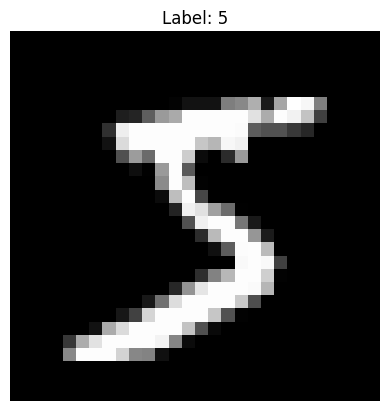

In [20]:
import matplotlib.pyplot as plt

# Pegar um exemplo do dataset
image, label = train_dataset[0]

print("Label:", label)
print("Shape do tensor:", image.shape)

# Mostrar a imagem
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

No MNIST, cada imagem tem forma `(1, 28, 28)`:
- `1`: número de canais;
- `28 × 28`: altura e largura.

Como nossa rede é totalmente conectada, vamos achatar cada imagem para um vetor de tamanho `784 = 28 × 28`.


## 7. Inspecionando um único mini-batch

Antes de treinar o modelo inteiro, vale muito a pena entender exatamente o que sai do `DataLoader`.


In [21]:
images, labels = next(iter(train_loader))

print("shape original de images:", images.shape)
print("shape de labels:", labels.shape)
print("dtype de images:", images.dtype)
print("dtype de labels:", labels.dtype)
print("primeiros labels:", labels[:10])


shape original de images: torch.Size([100, 1, 28, 28])
shape de labels: torch.Size([100])
dtype de images: torch.float32
dtype de labels: torch.int64
primeiros labels: tensor([1, 8, 7, 9, 9, 6, 1, 8, 9, 9])


Aqui vemos:
- `images.shape = (batch_size, 1, 28, 28)`
- `labels.shape = (batch_size,)`

Ou seja:
- temos um lote de imagens;
- cada imagem é monocromática;
- cada rótulo é um inteiro entre `0` e `9`.


In [22]:
images_flat = images.reshape(-1, 28 * 28)

print("shape após flatten:", images_flat.shape)

shape após flatten: torch.Size([100, 784])


A operação de flatten é essencial neste modelo:
- antes: `(batch_size, 1, 28, 28)`
- depois: `(batch_size, 784)`

Esse é um dos pontos em que alunos mais cometem erros de forma.


## 8. Um forward completo em um batch

Antes do loop de treino, vamos seguir o fluxo completo em um único mini-batch.


In [23]:
model = NeuralNet(input_size, hidden_size, num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

images = images.to(device)
labels = labels.to(device)
images_flat = images.reshape(-1, 28 * 28)

outputs = model(images_flat)

print("shape de outputs:", outputs.shape)
print("5 primeiros vetores de logits:")
print(outputs[:5])

shape de outputs: torch.Size([100, 10])
5 primeiros vetores de logits:
tensor([[-0.0773, -0.0041,  0.0272, -0.0380,  0.0186, -0.0203, -0.0083,  0.0038,
          0.1131,  0.0380],
        [-0.0553, -0.1954,  0.0470, -0.0218, -0.0852,  0.0693,  0.1762, -0.0598,
          0.1711,  0.0094],
        [-0.0305, -0.0990, -0.0275, -0.0372, -0.0521,  0.0010,  0.1545, -0.0652,
          0.1938, -0.0034],
        [ 0.0253,  0.0229,  0.0943,  0.0265, -0.0519,  0.0192,  0.1456, -0.0205,
          0.1156, -0.0398],
        [-0.1013, -0.0442,  0.0414, -0.0528, -0.0211,  0.0225,  0.2009,  0.0197,
          0.1326,  0.0159]], grad_fn=<SliceBackward0>)


A saída do modelo tem forma `(batch_size, 10)`, porque para cada imagem o modelo produz 10 logits, um para cada classe possível.


In [24]:
loss = criterion(outputs, labels)
print("loss =", loss.item())


loss = 2.2892467975616455


`CrossEntropyLoss` recebe:
- `outputs`: logits com forma `(batch_size, num_classes)`;
- `labels`: rótulos inteiros com forma `(batch_size,)`.

Não usamos vetores one-hot aqui.


In [25]:
optimizer.zero_grad()
loss.backward()

print("shape do gradiente de fc1.weight:", model.fc1.weight.grad.shape)
print("norma do gradiente de fc1.weight:", model.fc1.weight.grad.norm().item())

shape do gradiente de fc1.weight: torch.Size([500, 784])
norma do gradiente de fc1.weight: 0.5295398831367493


Após `loss.backward()`, cada parâmetro treinável passa a ter um gradiente armazenado em `.grad`.


In [26]:
optimizer.step()
print("Passo de otimização concluído.")


Passo de otimização concluído.


Agora o ciclo completo de treinamento já apareceu uma vez:

**forward → loss → backward → optimizer.step()**


## 9. Loop de treinamento completo

Agora vamos repetir esse processo ao longo de vários batches e épocas.


In [27]:
model = NeuralNet(input_size, hidden_size, num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)


In [28]:
import matplotlib.pyplot as plt

train_loss_history = []
test_accuracy_history = []

In [29]:
def evaluate(model, data_loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.reshape(-1, 28 * 28).to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    return 100 * correct / total


A função de avaliação:
- coloca o modelo em modo de avaliação com `model.eval()`;
- desliga o rastreamento de gradientes com `torch.no_grad()`.

Isso economiza memória e deixa explícito que não estamos treinando nessa etapa.


In [30]:
total_step = len(train_loader)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for i, (images, labels) in enumerate(train_loader):
        images = images.reshape(-1, 28 * 28).to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if (i + 1) % 100 == 0:
            print(
                f"Época [{epoch+1}/{num_epochs}], "
                f"Passo [{i+1}/{total_step}], "
                f"Loss: {loss.item():.4f}"
            )

    epoch_loss = running_loss / total_step
    epoch_acc = evaluate(model, test_loader, device)

    train_loss_history.append(epoch_loss)
    test_accuracy_history.append(epoch_acc)

    print(
        f"Fim da época {epoch+1}: "
        f"train_loss = {epoch_loss:.4f}, "
        f"test_accuracy = {epoch_acc:.2f}%"
    )


Época [1/5], Passo [100/600], Loss: 0.4329
Época [1/5], Passo [200/600], Loss: 0.3543
Época [1/5], Passo [300/600], Loss: 0.2295
Época [1/5], Passo [400/600], Loss: 0.1447
Época [1/5], Passo [500/600], Loss: 0.1301
Época [1/5], Passo [600/600], Loss: 0.1450
Fim da época 1: train_loss = 0.2952, test_accuracy = 95.23%
Época [2/5], Passo [100/600], Loss: 0.0912
Época [2/5], Passo [200/600], Loss: 0.0374
Época [2/5], Passo [300/600], Loss: 0.0835
Época [2/5], Passo [400/600], Loss: 0.0476
Época [2/5], Passo [500/600], Loss: 0.0806
Época [2/5], Passo [600/600], Loss: 0.1144
Fim da época 2: train_loss = 0.1181, test_accuracy = 97.15%
Época [3/5], Passo [100/600], Loss: 0.0539
Época [3/5], Passo [200/600], Loss: 0.0647
Época [3/5], Passo [300/600], Loss: 0.1261
Época [3/5], Passo [400/600], Loss: 0.0441
Época [3/5], Passo [500/600], Loss: 0.0434
Época [3/5], Passo [600/600], Loss: 0.0833
Fim da época 3: train_loss = 0.0769, test_accuracy = 97.50%
Época [4/5], Passo [100/600], Loss: 0.0570
Épo

Agora temos duas quantidades registradas ao final de cada época:
- loss média de treino;
- acurácia no conjunto de teste.


## 10. Visualizando o histórico de treinamento


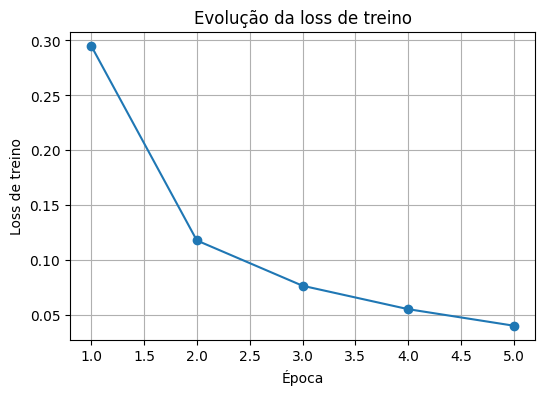

In [31]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, num_epochs + 1), train_loss_history, marker="o")
plt.xlabel("Época")
plt.ylabel("Loss de treino")
plt.title("Evolução da loss de treino")
plt.grid(True)
plt.show()


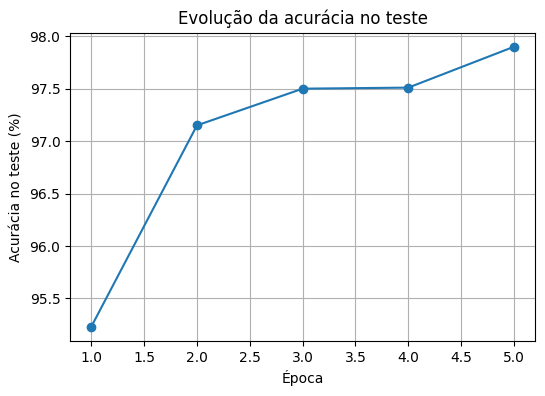

In [32]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, num_epochs + 1), test_accuracy_history, marker="o")
plt.xlabel("Época")
plt.ylabel("Acurácia no teste (%)")
plt.title("Evolução da acurácia no teste")
plt.grid(True)
plt.show()


Esses gráficos ajudam a tornar o treinamento menos “caixa-preta”:
- esperamos que a loss de treino diminua;
- esperamos que a acurácia de teste aumente, ao menos nas primeiras épocas.


## 11. Avaliação final

Vamos rodar uma avaliação final do modelo.


In [33]:
final_acc = evaluate(model, test_loader, device)
print(f"Acurácia final no conjunto de teste: {final_acc:.2f}%")

Acurácia final no conjunto de teste: 97.90%


In [34]:
torch.save(model.state_dict(), "model.ckpt")
print("Modelo salvo em model.ckpt")

Modelo salvo em model.ckpt


## 12. Visualizando algumas previsões

Depois de treinar, é útil olhar exemplos concretos para conectar a saída numérica do modelo com imagens reais.


In [35]:
model.eval()

images, labels = next(iter(test_loader))
images_device = images.reshape(-1, 28 * 28).to(device)

with torch.no_grad():
    outputs = model(images_device)
    preds = outputs.argmax(dim=1).cpu()


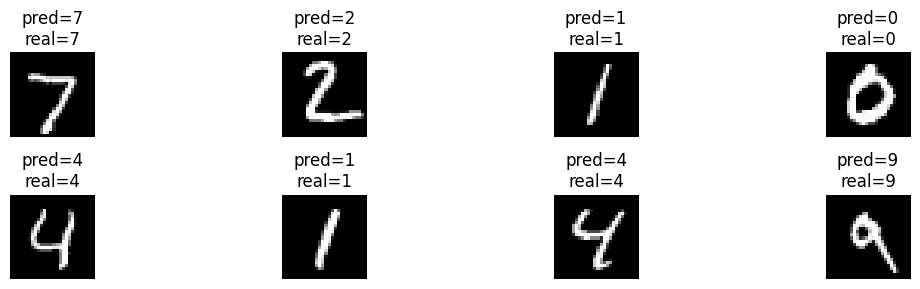

In [36]:
num_examples = 8

plt.figure(figsize=(12, 3))
for i in range(num_examples):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].squeeze(0), cmap="gray")
    plt.title(f"pred={preds[i].item()}\nreal={labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()


## 13. Erros comuns neste tipo de notebook

Alguns erros muito frequentes:

1. **Esquecer o flatten**  
   A rede espera entradas com forma `(batch_size, 784)`, não `(batch_size, 1, 28, 28)`.

2. **Aplicar `softmax` antes de `CrossEntropyLoss`**  
   Neste caso não é necessário, porque `nn.CrossEntropyLoss()` já trata isso internamente.

3. **Esquecer `optimizer.zero_grad()`**  
   Gradientes em PyTorch são acumulados por padrão.

4. **Avaliar sem `torch.no_grad()`**  
   Isso desperdiça memória e processamento.

5. **Esquecer `model.train()` e `model.eval()`**  
   Em redes com camadas como dropout e batch normalization, isso muda o comportamento do modelo.

6. **Confundir shapes de `outputs` e `labels`**  
   Para classificação multiclasse:
   - `outputs`: `(batch_size, num_classes)`
   - `labels`: `(batch_size,)`
